# 07 Model Comparison

Comparison of all trained models for handwritten Chinese character recognition.


In [1]:
from google.colab import drive

# Mount Google Drive to access saved model results
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Set paths





In [3]:
BASE_DIR = Path("/content/drive/MyDrive/Diploma/diploma_hccr")

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)


Base directory: /content/drive/MyDrive/Diploma/diploma_hccr
Results directory: /content/drive/MyDrive/Diploma/diploma_hccr/results
Figures directory: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures


## Load Model Summaries


In [4]:
summary_files = {
    "Simple CNN": RESULTS_DIR / "simple_cnn_5fold_summary.csv",
    "Improved CNN": RESULTS_DIR / "improved_cnn_summary.csv",
    "ResNet18": RESULTS_DIR / "resnet18_summary.csv",
    "LW-ViT": RESULTS_DIR / "lwvit_summary.csv",
    "PF-ViT": RESULTS_DIR / "pfvit_summary.csv"
}

cv_summary_files = {
    "Simple CNN": RESULTS_DIR / "simple_cnn_5fold_cross_validation_summary.csv",
    "Improved CNN": RESULTS_DIR / "improved_cnn_cross_validation_summary.csv",
    "ResNet18": RESULTS_DIR / "resnet18_cross_validation_summary.csv",
    "LW-ViT": RESULTS_DIR / "lwvit_cross_validation_summary.csv",
    "PF-ViT": RESULTS_DIR / "pfvit_cross_validation_summary.csv"
}

loaded_summaries = []
loaded_cv_summaries = {}

for model_name, file_path in summary_files.items():
    if file_path.exists():
        summary_df = pd.read_csv(file_path)
        summary_df["model_name"] = model_name
        loaded_summaries.append(summary_df)
        print(f"Loaded summary: {model_name}")
    else:
        print(f"Summary file not found for {model_name}: {file_path}")

for model_name, file_path in cv_summary_files.items():
    if file_path.exists():
        loaded_cv_summaries[model_name] = pd.read_csv(file_path)
        print(f"Loaded CV summary: {model_name}")
    else:
        print(f"CV summary file not found for {model_name}: {file_path}")

if len(loaded_summaries) == 0:
    raise FileNotFoundError("No summary files were found. Please check file paths.")

raw_comparison_df = pd.concat(loaded_summaries, ignore_index=True)

print("Summary files loaded:", len(loaded_summaries))
print("Cross-validation summaries loaded:", len(loaded_cv_summaries))


Loaded summary: Simple CNN
Loaded summary: Improved CNN
Loaded summary: ResNet18
Loaded summary: LW-ViT
Loaded summary: PF-ViT
Loaded CV summary: Simple CNN
Loaded CV summary: Improved CNN
Loaded CV summary: ResNet18
Loaded CV summary: LW-ViT
Loaded CV summary: PF-ViT
Summary files loaded: 5
Cross-validation summaries loaded: 5


## Standardize Column Names

Different model notebooks may save the same metric using slightly different column names. This section converts all summaries into one unified format.


In [5]:
def get_value_from_possible_columns(row, possible_columns):
    """
    Return the first available value from a list of possible column names.
    If none of the columns exist or all values are missing, return NaN.
    """
    for column in possible_columns:
        if column in row.index:
            value = row[column]
            if pd.notna(value):
                return value
    return np.nan


In [6]:
column_mapping = {
    "mean_validation_accuracy": [
        "mean_validation_accuracy",
        "validation_accuracy_mean",
        "mean_val_accuracy",
        "best_validation_accuracy",
        "validation_accuracy"
    ],
    "mean_validation_f1": [
        "mean_validation_f1",
        "validation_f1_mean",
        "mean_val_f1",
        "best_validation_f1",
        "validation_f1"
    ],
    "validation_accuracy_std": [
        "validation_accuracy_std",
        "std_validation_accuracy",
        "validation_std",
        "validation_accuracy_standard_deviation",
        "std_val_accuracy"
    ],
    "validation_f1_std": [
        "validation_f1_std",
        "std_validation_f1",
        "validation_f1_standard_deviation",
        "std_val_f1"
    ],
    "best_fold": [
        "best_fold",
        "fold"
    ],
    "best_validation_accuracy": [
        "best_validation_accuracy"
    ],
    "best_validation_f1": [
        "best_validation_f1"
    ],
    "test_accuracy": [
        "test_accuracy",
        "test_acc"
    ],
    "test_f1": [
        "test_f1",
        "test_macro_f1",
        "test_macro_f1_score"
    ],
    "number_of_parameters": [
        "number_of_parameters",
        "num_parameters",
        "parameters"
    ],
    "model_size_mb": [
        "model_size_mb",
        "model_size"
    ],
    "total_training_time": [
        "total_training_time",
        "training_time"
    ],
    "average_epoch_time": [
        "average_epoch_time"
    ]
}


## Create Unified Comparison Table


In [7]:
clean_rows = []

for _, row in raw_comparison_df.iterrows():
    clean_row = {
        "model_name": row["model_name"]
    }

    for standard_column, possible_columns in column_mapping.items():
        clean_row[standard_column] = get_value_from_possible_columns(row, possible_columns)

    clean_rows.append(clean_row)

comparison_table = pd.DataFrame(clean_rows)

comparison_table

,model_name,mean_validation_accuracy,mean_validation_f1,validation_accuracy_std,validation_f1_std,best_fold,best_validation_accuracy,best_validation_f1,test_accuracy,test_f1,number_of_parameters,model_size_mb,total_training_time,average_epoch_time
0,Simple CNN,0.971188,0.971213,0.001166,NaN,5,NaN,NaN,0.961861,0.961933,1431382,5.467674,6216.172852,124.225892
1,Improved CNN,0.974142,0.974166,0.000741,0.000728,5,0.975351,0.975350,0.965991,0.966045,3779222,14.433762,6546.621068,130.911878
2,ResNet18,0.967141,0.967182,0.002846,0.002872,4,0.971548,0.971589,0.960123,0.960368,11293878,43.119499,14447.737077,481.511566
3,LW-ViT,0.863036,0.862658,0.012392,0.012560,2,0.878790,0.878645,0.873619,0.873666,643190,2.453575,6650.716299,132.993487
4,PF-ViT,0.933521,0.933632,0.010996,0.010933,3,0.941296,0.941381,0.931896,0.931983,784982,2.995216,6569.983278,131.381553


## Add Cross-Validation Statistics


In [8]:
for index, row in comparison_table.iterrows():
    model_name = row["model_name"]

    if model_name in loaded_cv_summaries:
        cv_df = loaded_cv_summaries[model_name]

        if "best_validation_accuracy" in cv_df.columns:
            comparison_table.loc[index, "mean_validation_accuracy"] = cv_df["best_validation_accuracy"].mean()
            comparison_table.loc[index, "validation_accuracy_std"] = cv_df["best_validation_accuracy"].std()
            comparison_table.loc[index, "best_validation_accuracy"] = cv_df["best_validation_accuracy"].max()

            best_fold_index = cv_df["best_validation_accuracy"].idxmax()

            if "fold" in cv_df.columns:
                comparison_table.loc[index, "best_fold"] = int(cv_df.loc[best_fold_index, "fold"])
            else:
                comparison_table.loc[index, "best_fold"] = int(best_fold_index + 1)

        if "best_validation_f1" in cv_df.columns:
            comparison_table.loc[index, "mean_validation_f1"] = cv_df["best_validation_f1"].mean()
            comparison_table.loc[index, "validation_f1_std"] = cv_df["best_validation_f1"].std()
            comparison_table.loc[index, "best_validation_f1"] = cv_df["best_validation_f1"].max()

# Sort models by test accuracy from best to worst
comparison_table = comparison_table.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

comparison_table.insert(0, "rank", range(1, len(comparison_table) + 1))

comparison_table


,rank,model_name,mean_validation_accuracy,mean_validation_f1,validation_accuracy_std,validation_f1_std,best_fold,best_validation_accuracy,best_validation_f1,test_accuracy,test_f1,number_of_parameters,model_size_mb,total_training_time,average_epoch_time
0,1,Improved CNN,0.974142,0.974166,0.000741,0.000728,5,0.975351,0.975350,0.965991,0.966045,3779222,14.433762,6546.621068,130.911878
1,2,Simple CNN,0.971188,0.971213,0.001166,0.001163,5,0.972974,0.972997,0.961861,0.961933,1431382,5.467674,6216.172852,124.225892
2,3,ResNet18,0.967141,0.967182,0.002846,0.002872,4,0.971548,0.971589,0.960123,0.960368,11293878,43.119499,14447.737077,481.511566
3,4,PF-ViT,0.933521,0.933632,0.010996,0.010933,3,0.941296,0.941381,0.931896,0.931983,784982,2.995216,6569.983278,131.381553
4,5,LW-ViT,0.863036,0.862658,0.012392,0.012560,2,0.878790,0.878645,0.873619,0.873666,643190,2.453575,6650.716299,132.993487


## Save Unified Comparison Table


In [9]:
COMPARISON_PATH = RESULTS_DIR / "model_comparison_summary.csv"

comparison_table.to_csv(COMPARISON_PATH, index=False)

print("Unified model comparison summary saved to:", COMPARISON_PATH)
comparison_table


Unified model comparison summary saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/model_comparison_summary.csv


,rank,model_name,mean_validation_accuracy,mean_validation_f1,validation_accuracy_std,validation_f1_std,best_fold,best_validation_accuracy,best_validation_f1,test_accuracy,test_f1,number_of_parameters,model_size_mb,total_training_time,average_epoch_time
0,1,Improved CNN,0.974142,0.974166,0.000741,0.000728,5,0.975351,0.975350,0.965991,0.966045,3779222,14.433762,6546.621068,130.911878
1,2,Simple CNN,0.971188,0.971213,0.001166,0.001163,5,0.972974,0.972997,0.961861,0.961933,1431382,5.467674,6216.172852,124.225892
2,3,ResNet18,0.967141,0.967182,0.002846,0.002872,4,0.971548,0.971589,0.960123,0.960368,11293878,43.119499,14447.737077,481.511566
3,4,PF-ViT,0.933521,0.933632,0.010996,0.010933,3,0.941296,0.941381,0.931896,0.931983,784982,2.995216,6569.983278,131.381553
4,5,LW-ViT,0.863036,0.862658,0.012392,0.012560,2,0.878790,0.878645,0.873619,0.873666,643190,2.453575,6650.716299,132.993487


In [10]:
display_table = comparison_table.copy()

# Add readable columns for the final thesis table
display_table["parameters_million"] = display_table["number_of_parameters"] / 1_000_000
display_table["training_time_minutes"] = display_table["total_training_time"] / 60

final_display_columns = [
    "rank",
    "model_name",
    "mean_validation_accuracy",
    "mean_validation_f1",
    "validation_accuracy_std",
    "validation_f1_std",
    "best_fold",
    "best_validation_accuracy",
    "best_validation_f1",
    "test_accuracy",
    "test_f1",
    "parameters_million",
    "model_size_mb",
    "training_time_minutes",
    "average_epoch_time"
]

final_table = display_table[final_display_columns].copy()

final_table = final_table.rename(columns={
    "rank": "Rank",
    "model_name": "Model",
    "mean_validation_accuracy": "Mean Val Accuracy",
    "mean_validation_f1": "Mean Val F1",
    "validation_accuracy_std": "Val Accuracy Std",
    "validation_f1_std": "Val F1 Std",
    "best_fold": "Best Fold",
    "best_validation_accuracy": "Best Val Accuracy",
    "best_validation_f1": "Best Val F1",
    "test_accuracy": "Test Accuracy",
    "test_f1": "Test F1",
    "parameters_million": "Parameters (M)",
    "model_size_mb": "Model Size (MB)",
    "training_time_minutes": "Training Time (min)",
    "average_epoch_time": "Avg Epoch Time (s)"
})

metric_columns = [
    "Mean Val Accuracy",
    "Mean Val F1",
    "Val Accuracy Std",
    "Val F1 Std",
    "Best Val Accuracy",
    "Best Val F1",
    "Test Accuracy",
    "Test F1"
]

for column in metric_columns:
    final_table[column] = final_table[column].round(4)

final_table["Parameters (M)"] = final_table["Parameters (M)"].round(2)
final_table["Model Size (MB)"] = final_table["Model Size (MB)"].round(2)
final_table["Training Time (min)"] = final_table["Training Time (min)"].round(1)
final_table["Avg Epoch Time (s)"] = final_table["Avg Epoch Time (s)"].round(1)

final_table = final_table.fillna("-")

final_table


,Rank,Model,Mean Val Accuracy,Mean Val F1,Val Accuracy Std,Val F1 Std,Best Fold,Best Val Accuracy,Best Val F1,Test Accuracy,Test F1,Parameters (M),Model Size (MB),Training Time (min),Avg Epoch Time (s)
0,1,Improved CNN,0.9741,0.9742,0.0007,0.0007,5,0.9754,0.9754,0.9660,0.9660,3.78,14.43,109.1,130.9
1,2,Simple CNN,0.9712,0.9712,0.0012,0.0012,5,0.9730,0.9730,0.9619,0.9619,1.43,5.47,103.6,124.2
2,3,ResNet18,0.9671,0.9672,0.0028,0.0029,4,0.9715,0.9716,0.9601,0.9604,11.29,43.12,240.8,481.5
3,4,PF-ViT,0.9335,0.9336,0.0110,0.0109,3,0.9413,0.9414,0.9319,0.9320,0.78,3.00,109.5,131.4
4,5,LW-ViT,0.8630,0.8627,0.0124,0.0126,2,0.8788,0.8786,0.8736,0.8737,0.64,2.45,110.8,133.0


## Save Final Table


In [11]:
FINAL_TABLE_PATH = RESULTS_DIR / "model_comparison_final_table.csv"

final_table.to_csv(FINAL_TABLE_PATH, index=False)

print("Final clean comparison table saved to:", FINAL_TABLE_PATH)
final_table


Final clean comparison table saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/model_comparison_final_table.csv


,Rank,Model,Mean Val Accuracy,Mean Val F1,Val Accuracy Std,Val F1 Std,Best Fold,Best Val Accuracy,Best Val F1,Test Accuracy,Test F1,Parameters (M),Model Size (MB),Training Time (min),Avg Epoch Time (s)
0,1,Improved CNN,0.9741,0.9742,0.0007,0.0007,5,0.9754,0.9754,0.9660,0.9660,3.78,14.43,109.1,130.9
1,2,Simple CNN,0.9712,0.9712,0.0012,0.0012,5,0.9730,0.9730,0.9619,0.9619,1.43,5.47,103.6,124.2
2,3,ResNet18,0.9671,0.9672,0.0028,0.0029,4,0.9715,0.9716,0.9601,0.9604,11.29,43.12,240.8,481.5
3,4,PF-ViT,0.9335,0.9336,0.0110,0.0109,3,0.9413,0.9414,0.9319,0.9320,0.78,3.00,109.5,131.4
4,5,LW-ViT,0.8630,0.8627,0.0124,0.0126,2,0.8788,0.8786,0.8736,0.8737,0.64,2.45,110.8,133.0


## Select the Best Model


In [12]:
best_model_by_accuracy = comparison_table.sort_values(
    by="test_accuracy",
    ascending=False
).iloc[0]

print("Best model based on test accuracy")
print("-" * 40)
print("Model:", best_model_by_accuracy["model_name"])
print("Test accuracy:", round(best_model_by_accuracy["test_accuracy"], 6))
print("Test macro F1-score:", round(best_model_by_accuracy["test_f1"], 6))
print("Number of parameters:", int(best_model_by_accuracy["number_of_parameters"]))

if pd.notna(best_model_by_accuracy["model_size_mb"]):
    print("Model size:", round(best_model_by_accuracy["model_size_mb"], 2), "MB")


Best model based on test accuracy
----------------------------------------
Model: Improved CNN
Test accuracy: 0.965991
Test macro F1-score: 0.966045
Number of parameters: 3779222
Model size: 14.43 MB


In [13]:
smallest_model = comparison_table.sort_values(
    by="number_of_parameters",
    ascending=True
).iloc[0]

print("Smallest model based on number of parameters")
print("-" * 40)
print("Model:", smallest_model["model_name"])
print("Number of parameters:", int(smallest_model["number_of_parameters"]))
print("Test accuracy:", round(smallest_model["test_accuracy"], 6))
print("Test macro F1-score:", round(smallest_model["test_f1"], 6))


Smallest model based on number of parameters
----------------------------------------
Model: LW-ViT
Number of parameters: 643190
Test accuracy: 0.873619
Test macro F1-score: 0.873666


## Visualization: Test Accuracy Comparison


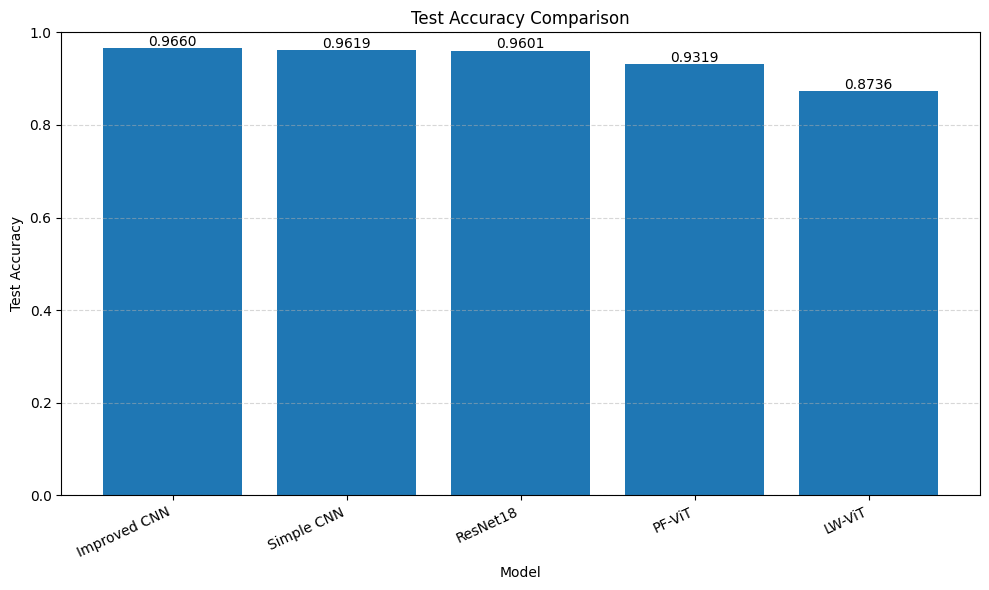

Saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/model_test_accuracy_comparison.png


In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_table["model_name"],
    comparison_table["test_accuracy"]
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for index, value in enumerate(comparison_table["test_accuracy"]):
    plt.text(
        index,
        value + 0.005,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

accuracy_plot_path = FIGURES_DIR / "model_test_accuracy_comparison.png"
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", accuracy_plot_path)


## Visualization: Test Macro F1-score Comparison


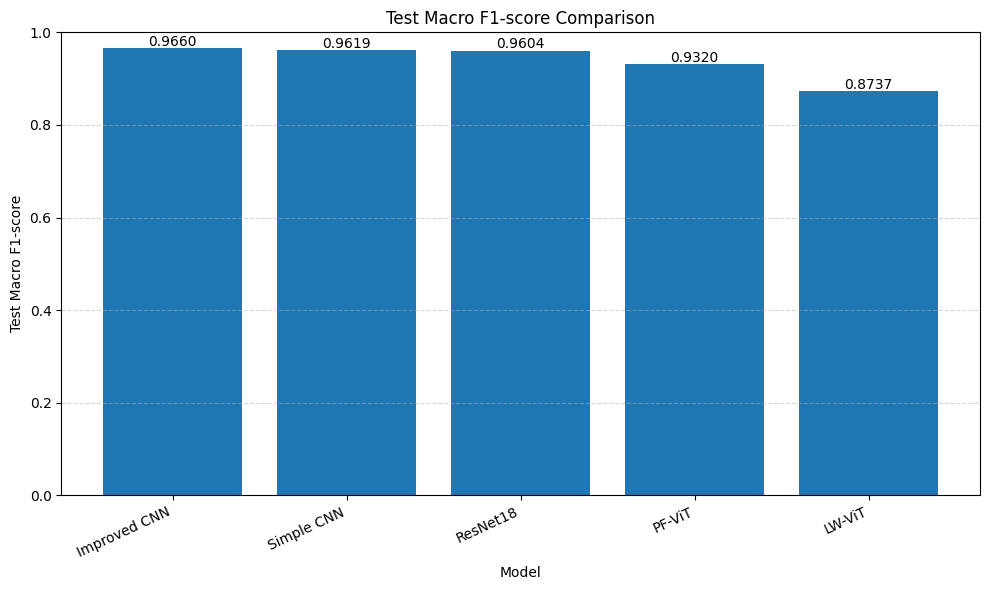

Saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/model_test_f1_comparison.png


In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_table["model_name"],
    comparison_table["test_f1"]
)

plt.title("Test Macro F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Test Macro F1-score")
plt.ylim(0, 1)

for index, value in enumerate(comparison_table["test_f1"]):
    plt.text(
        index,
        value + 0.005,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

f1_plot_path = FIGURES_DIR / "model_test_f1_comparison.png"
plt.savefig(f1_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", f1_plot_path)


## Visualization: Number of Parameters Comparison


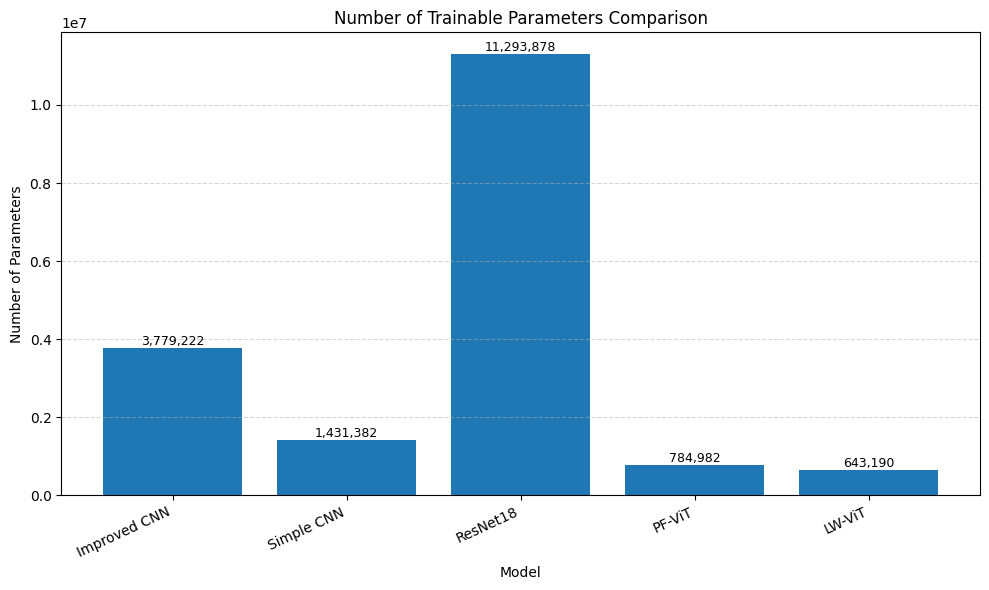

Saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/model_parameters_comparison.png


In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_table["model_name"],
    comparison_table["number_of_parameters"]
)

plt.title("Number of Trainable Parameters Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")

for index, value in enumerate(comparison_table["number_of_parameters"]):
    plt.text(
        index,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

parameters_plot_path = FIGURES_DIR / "model_parameters_comparison.png"
plt.savefig(parameters_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", parameters_plot_path)


## Visualization: Model Size Comparison


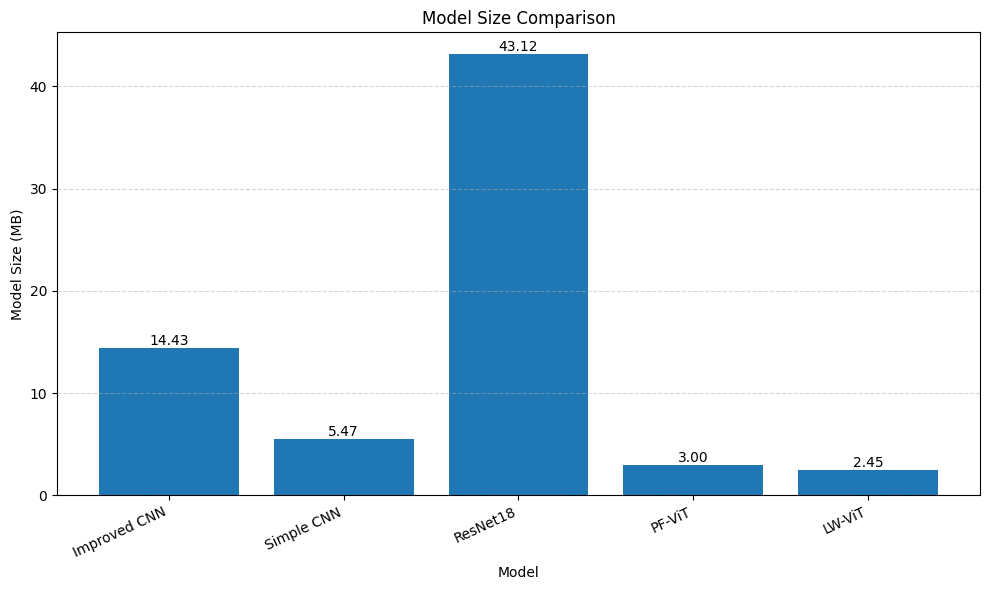

Saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/model_size_comparison.png


In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_table["model_name"],
    comparison_table["model_size_mb"]
)

plt.title("Model Size Comparison")
plt.xlabel("Model")
plt.ylabel("Model Size (MB)")

for index, value in enumerate(comparison_table["model_size_mb"]):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

size_plot_path = FIGURES_DIR / "model_size_comparison.png"
plt.savefig(size_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", size_plot_path)


## Visualization: Accuracy vs Number of Parameters


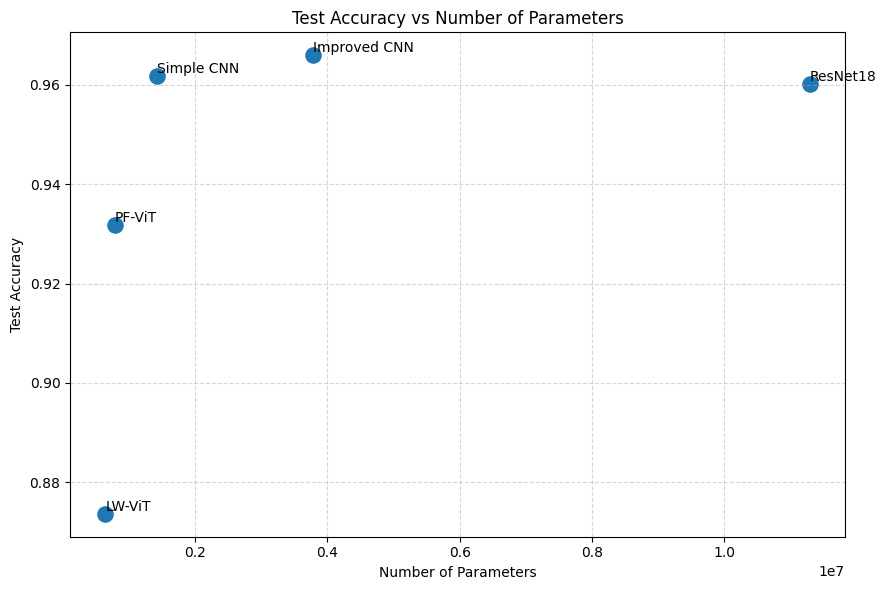

Saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/accuracy_vs_parameters.png


In [19]:
plt.figure(figsize=(9, 6))

plt.scatter(
    comparison_table["number_of_parameters"],
    comparison_table["test_accuracy"],
    s=120
)

for _, row in comparison_table.iterrows():
    plt.text(
        row["number_of_parameters"],
        row["test_accuracy"],
        row["model_name"],
        fontsize=10,
        ha="left",
        va="bottom"
    )

plt.title("Test Accuracy vs Number of Parameters")
plt.xlabel("Number of Parameters")
plt.ylabel("Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

accuracy_parameters_plot_path = FIGURES_DIR / "accuracy_vs_parameters.png"
plt.savefig(accuracy_parameters_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", accuracy_parameters_plot_path)


## Visualization: Accuracy vs Model Size


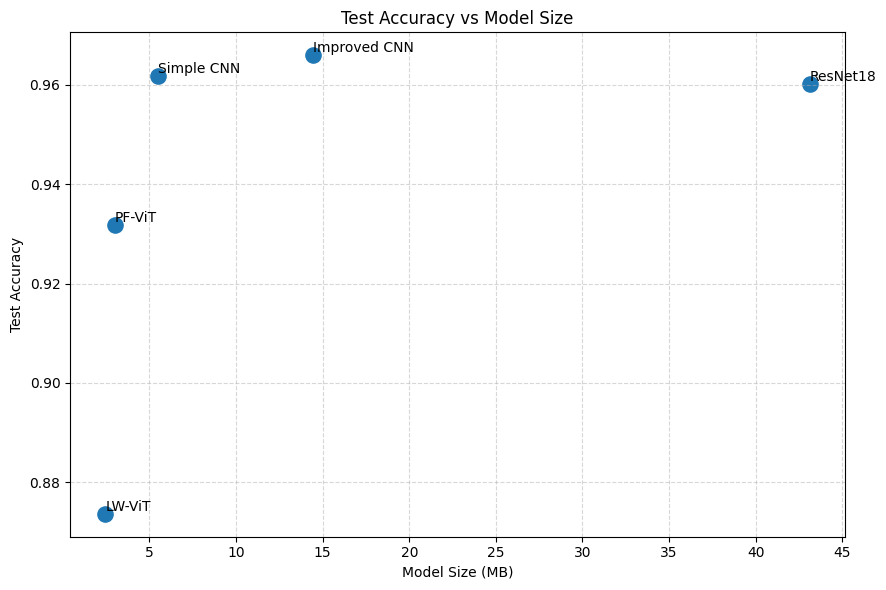

Saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/accuracy_vs_model_size.png


In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    comparison_table["model_size_mb"],
    comparison_table["test_accuracy"],
    s=120
)

for _, row in comparison_table.iterrows():
    plt.text(
        row["model_size_mb"],
        row["test_accuracy"],
        row["model_name"],
        fontsize=10,
        ha="left",
        va="bottom"
    )

plt.title("Test Accuracy vs Model Size")
plt.xlabel("Model Size (MB)")
plt.ylabel("Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

accuracy_size_plot_path = FIGURES_DIR / "accuracy_vs_model_size.png"
plt.savefig(accuracy_size_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", accuracy_size_plot_path)


## Generate Experimental Conclusion


In [21]:
best_accuracy_model = comparison_table.sort_values(
    by="test_accuracy",
    ascending=False
).iloc[0]

best_f1_model = comparison_table.sort_values(
    by="test_f1",
    ascending=False
).iloc[0]

smallest_model = comparison_table.sort_values(
    by="number_of_parameters",
    ascending=True
).iloc[0]

print("Experimental conclusion")
print("=" * 70)

print(
    f"The best model by test accuracy is {best_accuracy_model['model_name']} "
    f"with a test accuracy of {best_accuracy_model['test_accuracy']:.4f} "
    f"and a test macro F1-score of {best_accuracy_model['test_f1']:.4f}."
)

print(
    f"The best model by test macro F1-score is {best_f1_model['model_name']} "
    f"with a test macro F1-score of {best_f1_model['test_f1']:.4f}."
)

print(
    f"The smallest model is {smallest_model['model_name']} "
    f"with {int(smallest_model['number_of_parameters']):,} trainable parameters "
    f"and a test accuracy of {smallest_model['test_accuracy']:.4f}."
)

print("\nRecommended model for the final software module:")
print(best_accuracy_model["model_name"])


Experimental conclusion
The best model by test accuracy is Improved CNN with a test accuracy of 0.9660 and a test macro F1-score of 0.9660.
The best model by test macro F1-score is Improved CNN with a test macro F1-score of 0.9660.
The smallest model is LW-ViT with 643,190 trainable parameters and a test accuracy of 0.8736.

Recommended model for the final software module:
Improved CNN


## Save Text Conclusion


In [22]:
CONCLUSION_PATH = RESULTS_DIR / "model_comparison_conclusion.txt"

conclusion_text = f"""
Experimental Model Comparison Conclusion

The best model by test accuracy is {best_accuracy_model['model_name']} with:
- Test accuracy: {best_accuracy_model['test_accuracy']:.4f}
- Test macro F1-score: {best_accuracy_model['test_f1']:.4f}
- Number of parameters: {int(best_accuracy_model['number_of_parameters']):,}

The best model by test macro F1-score is {best_f1_model['model_name']} with:
- Test macro F1-score: {best_f1_model['test_f1']:.4f}
- Test accuracy: {best_f1_model['test_accuracy']:.4f}

The smallest model is {smallest_model['model_name']} with:
- Number of parameters: {int(smallest_model['number_of_parameters']):,}
- Test accuracy: {smallest_model['test_accuracy']:.4f}
- Test macro F1-score: {smallest_model['test_f1']:.4f}

Based on the comparison, {best_accuracy_model['model_name']} is recommended as the final recognition model for the software module because it achieved the highest test accuracy and strong macro F1-score.
"""

with open(CONCLUSION_PATH, "w", encoding="utf-8") as file:
    file.write(conclusion_text)

print("Conclusion saved to:", CONCLUSION_PATH)
print(conclusion_text)


Conclusion saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/model_comparison_conclusion.txt

Experimental Model Comparison Conclusion

The best model by test accuracy is Improved CNN with:
- Test accuracy: 0.9660
- Test macro F1-score: 0.9660
- Number of parameters: 3,779,222

The best model by test macro F1-score is Improved CNN with:
- Test macro F1-score: 0.9660
- Test accuracy: 0.9660

The smallest model is LW-ViT with:
- Number of parameters: 643,190
- Test accuracy: 0.8736
- Test macro F1-score: 0.8737

Based on the comparison, Improved CNN is recommended as the final recognition model for the software module because it achieved the highest test accuracy and strong macro F1-score.

